In [1]:
#get the real dataset
!curl -L -o socofing.zip https://www.kaggle.com/api/v1/datasets/download/ruizgara/socofing

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  837M  100  837M    0     0   124M      0  0:00:06  0:00:06 --:--:--  106M


In [2]:
!unzip -qq /content/socofing.zip

In [3]:
#get the testing external dataset
!curl -L -o biometric-fingerprint-spoofing.zip https://www.kaggle.com/api/v1/datasets/download/unidpro/biometric-fingerprint-spoofing
!unzip -qq  biometric-fingerprint-spoofing.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  129M  100  129M    0     0  72.8M      0  0:00:01  0:00:01 --:--:--  118M


In [ ]:
# Install required packages if not already installed
!pip -qq install opencv-python scikit-image scikit-learn tensorflow pandas matplotlib seaborn

In [22]:
# Core libraries
import os
import cv2
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Feature extraction
from skimage.feature import hog

# Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, models

In [6]:
# Root path of SOCOFing dataset
dataset_path = "SOCOFing"

# Real fingerprints
real_path = os.path.join(dataset_path, "Real")

# Altered fingerprints (spoofed)
altered_easy = os.path.join(dataset_path, "Altered/Altered-Easy")
altered_medium = os.path.join(dataset_path, "Altered/Altered-Medium")
altered_hard = os.path.join(dataset_path, "Altered/Altered-Hard")

In [7]:
def count_images(folder):
    return len(os.listdir(folder))

print("Real images:", count_images(real_path))
print("Altered Easy:", count_images(altered_easy))
print("Altered Medium:", count_images(altered_medium))
print("Altered Hard:", count_images(altered_hard))

Real images: 6000
Altered Easy: 17931
Altered Medium: 17067
Altered Hard: 14272


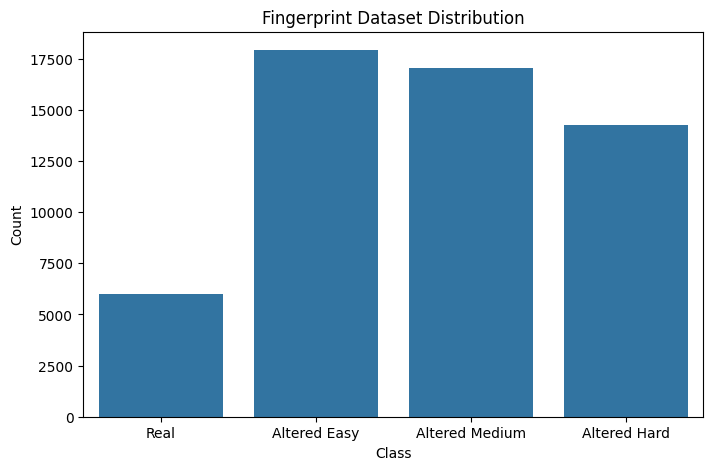

In [8]:
# Create dataframe for visualization
data = {
    "Class": ["Real", "Altered Easy", "Altered Medium", "Altered Hard"],
    "Count": [
        count_images(real_path),
        count_images(altered_easy),
        count_images(altered_medium),
        count_images(altered_hard)
    ]
}

df = pd.DataFrame(data)

# Plot class distribution
plt.figure(figsize=(8,5))
sns.barplot(x="Class", y="Count", data=df)
plt.title("Fingerprint Dataset Distribution")
plt.show()

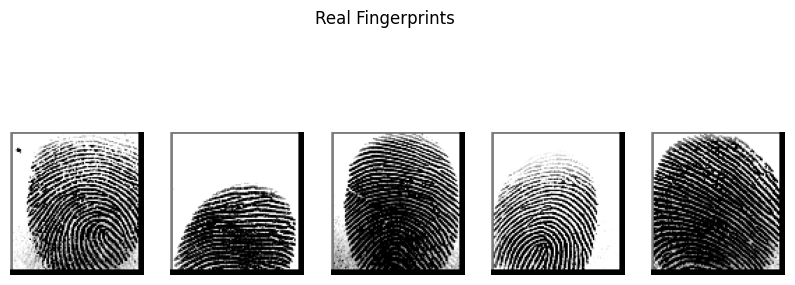

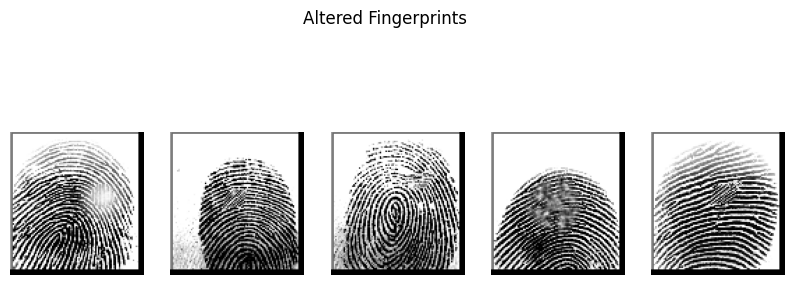

In [9]:
# Display some fingerprint images
def show_samples(folder, title):

    plt.figure(figsize=(10,4))

    for i, img_name in enumerate(os.listdir(folder)[:5]):

        img = cv2.imread(os.path.join(folder, img_name), cv2.IMREAD_GRAYSCALE)

        plt.subplot(1,5,i+1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

show_samples(real_path, "Real Fingerprints")
show_samples(altered_easy, "Altered Fingerprints")

In [3]:
import shutil
import os

dataset_path = "SOCOFing"

real_path = os.path.join(dataset_path, "Real")
altered_easy = os.path.join(dataset_path, "Altered/Altered-Easy")
altered_medium = os.path.join(dataset_path, "Altered/Altered-Medium")
altered_hard = os.path.join(dataset_path, "Altered/Altered-Hard")

os.makedirs("dataset/real",exist_ok=True)
os.makedirs("dataset/spoof",exist_ok=True)

for img in os.listdir(real_path):
    shutil.copy(os.path.join(real_path,img),"dataset/real")

for folder in [altered_easy,altered_medium,altered_hard]:

    for img in os.listdir(folder):
        shutil.copy(os.path.join(folder,img),"dataset/spoof")

In [4]:
#Image Generator
from skimage.feature import hog

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

IMG_SIZE = 128
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15
)

In [30]:
#Training Generator
train_generator = datagen.flow_from_directory(
    "dataset",
    target_size=(IMG_SIZE,IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=False
)
#validation
val_generator = datagen.flow_from_directory(
    "dataset",
    target_size=(IMG_SIZE,IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

Found 20361 images belonging to 2 classes.
Found 3592 images belonging to 2 classes.


In [31]:
#CNN model
def build_cnn():

    model = models.Sequential()

    model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,1)))
    model.add(layers.MaxPooling2D())

    model.add(layers.Conv2D(64,(3,3),activation='relu'))
    model.add(layers.MaxPooling2D())

    model.add(layers.Conv2D(128,(3,3),activation='relu'))
    model.add(layers.MaxPooling2D())

    model.add(layers.Flatten())

    model.add(layers.Dense(128,activation='relu'))
    model.add(layers.Dense(1,activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [32]:
#Train CNN
cnn_model = build_cnn()

history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


637/637 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.8013 - loss: 0.5080 - val_accuracy: 0.8655 - val_loss: 0.3701
Epoch 2/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.8849 - loss: 0.2666 - val_accuracy: 0.9084 - val_loss: 0.2305
Epoch 3/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.9162 - loss: 0.1924 - val_accuracy: 0.9349 - val_loss: 0.1615
Epoch 4/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.9308 - loss: 0.1652 - val_accuracy: 0.9385 - val_loss: 0.1722
Epoch 5/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.9446 - loss: 0.1310 - val_accuracy: 0.9619 - val_loss: 0.1123
Epoch 6/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9493 - loss: 0.1391 - val_accuracy: 0.9582 - val_loss: 0.1153
Epoch 7/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.9620 - loss: 0.0933 - val_accuracy: 0.9674 - val_loss: 0.0955
Epoch 8/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.9668 - loss: 0.0840 - val_accurac

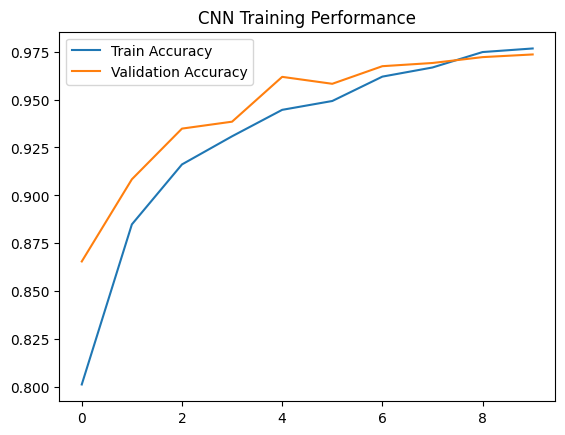

In [33]:
#CNN Training Curve
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],label="Train Accuracy")
plt.plot(history.history['val_accuracy'],label="Validation Accuracy")

plt.title("CNN Training Performance")
plt.legend()

plt.show()

In [34]:
#Hybrid CNN
def build_hybrid_cnn():

    model = models.Sequential()

    model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,1)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D())

    model.add(layers.Conv2D(64,(3,3),activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D())

    model.add(layers.Conv2D(128,(3,3),activation='relu'))
    model.add(layers.MaxPooling2D())

    model.add(layers.Flatten())

    model.add(layers.Dense(256,activation='relu'))
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(1,activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

hybrid_model = build_hybrid_cnn()
hybrid_model_history=hybrid_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.8810 - loss: 1.8423 - val_accuracy: 0.9365 - val_loss: 0.1602
Epoch 2/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.9538 - loss: 0.1348 - val_accuracy: 0.9669 - val_loss: 0.0905
Epoch 3/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.9625 - loss: 0.1120 - val_accuracy: 0.9568 - val_loss: 0.1375
Epoch 4/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.9722 - loss: 0.0791 - val_accuracy: 0.9633 - val_loss: 0.1033
Epoch 5/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.9743 - loss: 0.0773 - val_accuracy: 0.9719 - val_loss: 0.0776
Epoch 6/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.9805 - loss: 0.0565 - val_accuracy: 0.9644 - val_loss: 0.1043
Epoch 7/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.9850 - loss: 0.0416 - val_accuracy: 0.9499 - val_loss: 0.2399
Epoch 8/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.9786 - loss: 0.0656 - 

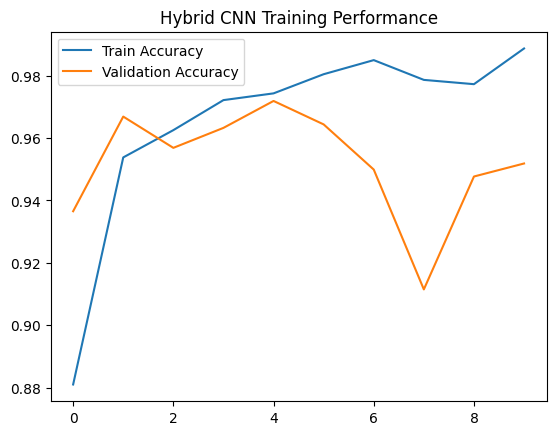

In [35]:
plt.plot(hybrid_model_history.history['accuracy'],label="Train Accuracy")
plt.plot(hybrid_model_history.history['val_accuracy'],label="Validation Accuracy")

plt.title("Hybrid CNN Training Performance")
plt.legend()

plt.show()

In [18]:
#Classical ML Models (Sampling)
#load only a subset for ML models.
import cv2
import numpy as np
SAMPLE_SIZE = 10000
IMG_SIZE = 128

images = []
labels = []

def load_sample(folder,label):

    files = os.listdir(folder)[:SAMPLE_SIZE]

    for file in files:

        img = cv2.imread(os.path.join(folder,file),cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))

        images.append(img)
        labels.append(label)

load_sample("dataset/real",1)
load_sample("dataset/spoof",0)

X = np.array(images)
y = np.array(labels)

In [20]:
#HOG Feature Extraction
from sklearn.model_selection import train_test_split

def extract_features(images):

    features=[]

    for img in images:

        hog_features = hog(
            img,
            pixels_per_cell=(16,16),
            cells_per_block=(2,2)
        )

        features.append(hog_features)

    return np.array(features)

X_feat = extract_features(X)
#Train Test Split
X_train,X_test,y_train,y_test = train_test_split(
    X_feat,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
#Train SVM
svm = SVC(kernel='rbf')

svm.fit(X_train,y_train)

svm_pred = svm.predict(X_test)

In [24]:
#Random Forest
rf = RandomForestClassifier(n_estimators=200)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

In [37]:
#Evaluation Metrics (Security Metrics)
from sklearn.metrics import confusion_matrix

def evaluate_model(y_true, y_pred):

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)

    FAR = fp / (fp + tn)
    FRR = fn / (fn + tp)

    precision = tp / (tp + fp)
    recall = tp / (tp + fn)

    print("Accuracy:", round(accuracy,4))
    print("FAR:", round(FAR,4))
    print("FRR:", round(FRR,4))
    print("Precision:", round(precision,4))
    print("Recall:", round(recall,4))

    return accuracy, FAR, FRR

cnn_pred_prob = cnn_model.predict(val_generator)

cnn_pred = (cnn_pred_prob > 0.5).astype(int)
y_true_cnn = val_generator.classes
print("CNN Results")
cnn_acc, cnn_far, cnn_frr = evaluate_model(y_true_cnn, cnn_pred)
hybrid_pred_prob = hybrid_model.predict(val_generator)

hybrid_pred = (hybrid_pred_prob > 0.5).astype(int)
print("Hybrid CNN Results")
hybrid_acc, hybrid_far, hybrid_frr = evaluate_model(y_true_cnn, hybrid_pred)

svm_pred = svm.predict(X_test)
print("SVM Results")

svm_acc, svm_far, svm_frr = evaluate_model(y_test, svm_pred)

rf_pred = rf.predict(X_test)
print("\nRandom Forest Results")

rf_acc, rf_far, rf_frr = evaluate_model(y_test, rf_pred)

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
CNN Results
Accuracy: 0.9736
FAR: 0.0811
FRR: 0.0082
Precision: 0.9734
Recall: 0.9918
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
Hybrid CNN Results
Accuracy: 0.9518
FAR: 0.1689
FRR: 0.0078
Precision: 0.9462
Recall: 0.9922
SVM Results
Accuracy: 0.9338
FAR: 0.056
FRR: 0.0837
Precision: 0.9056
Recall: 0.9163

Random Forest Results
Accuracy: 0.8678
FAR: 0.0545
FRR: 0.2646
Precision: 0.8878
Recall: 0.7354


In [39]:
#External Dataset Testing
def load_external_dataset(path):

    images = []
    labels = []

    for folder,label in [("Real",1),("Print",0),("Replay",0)]:

        folder_path = os.path.join(path,folder)

        for file in os.listdir(folder_path):

            img = cv2.imread(os.path.join(folder_path,file),cv2.IMREAD_GRAYSCALE) #convert to grayscale

            img = cv2.resize(img,(128,128))

            img = img/255.0

            images.append(img)
            labels.append(label)

    X = np.array(images).reshape(-1,128,128,1)
    y = np.array(labels)

    return X,y

In [41]:
external_path = "Samsung Galaxy A53 5G"

X_ext, y_ext = load_external_dataset(external_path)

cnn_ext_pred_prob = cnn_model.predict(X_ext)
cnn_ext_pred = (cnn_ext_pred_prob > 0.5).astype(int)

print("\nCNN External Dataset Results")
cnn_ext_acc, cnn_ext_far, cnn_ext_frr = evaluate_model(y_ext, cnn_ext_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

CNN External Dataset Results
Accuracy: 0.3333
FAR: 1.0
FRR: 0.0
Precision: 0.3333
Recall: 1.0


In [42]:
hybrid_ext_pred_prob = hybrid_model.predict(X_ext)

hybrid_ext_pred = (hybrid_ext_pred_prob > 0.5).astype(int)

print("\nHybrid CNN External Dataset Results")
hybrid_ext_acc, hybrid_ext_far, hybrid_ext_frr = evaluate_model(y_ext, hybrid_ext_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step

Hybrid CNN External Dataset Results
Accuracy: 0.5
FAR: 0.45
FRR: 0.6
Precision: 0.3077
Recall: 0.4


In [62]:
def extract_features(images):

    features = []

    for img in images:

        img = img.reshape(IMG_SIZE,IMG_SIZE)

        hog_features = hog(
            img,
            pixels_per_cell=(16,16),
            cells_per_block=(2,2)
        )

        features.append(hog_features)

    return np.array(features)

In [63]:
X_ext_features = extract_features(X_ext)
svm_ext_pred = svm.predict(X_ext_features)

print("\nSVM External Dataset Results")

svm_ext_acc, svm_ext_far, svm_ext_frr = evaluate_model(y_ext, svm_ext_pred)
rf_ext_pred = rf.predict(X_ext_features)

print("\nRandom Forest External Dataset Results")
rf_ext_acc, rf_ext_far, rf_ext_frr = evaluate_model(y_ext, rf_ext_pred)


SVM External Dataset Results
Accuracy: 0.7
FAR: 0.0
FRR: 0.9
Precision: 1.0
Recall: 0.1

Random Forest External Dataset Results
Accuracy: 0.6667
FAR: 0.0
FRR: 1.0
Precision: nan
Recall: 0.0


/tmp/ipykernel_7169/3839806913.py:13: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


In [64]:
import pandas as pd

external_results = pd.DataFrame({

"Model":[
"SVM",
"Random Forest",
"CNN",
"Hybrid CNN"
],

"Accuracy":[
svm_ext_acc,
rf_ext_acc,
cnn_ext_acc,
hybrid_ext_acc
],

"FAR":[
svm_ext_far,
rf_ext_far,
cnn_ext_far,
hybrid_ext_far
],

"FRR":[
svm_ext_frr,
rf_ext_frr,
cnn_ext_frr,
hybrid_ext_frr
]

})

print("\nExternal Dataset Performance")

print(external_results)
#Hybrid CNN demonstrates better trade-off between security and usability than compared to the other models.


External Dataset Performance
           Model  Accuracy   FAR  FRR
0            SVM  0.700000  0.00  0.9
1  Random Forest  0.666667  0.00  1.0
2            CNN  0.333333  1.00  0.0
3     Hybrid CNN  0.500000  0.45  0.6
